In [1]:
import numpy as np
import ldpc.mod2.mod2_numpy as mod2
import numpy.typing as npt

"""
def _get_stabilizers(self):
    arr = []
    qub_index = {q:i for i,q in enumerate(self.qubits)}
    n = len(self.qubits)
    for tile in self._tiles:
        subarr = np.zeros(n)
        for q in tile.qubits:
            subarr[qub_index[qtoid[q]]] = 1
        arr.append(subarr)

    return arr"""

def _compute_logical(m1: npt.NDArray[np.int8], m2: npt.NDArray[np.int8]) -> npt.NDArray[np.int8]:
    """Compute the logical matrix L."""
    ker_m1 = mod2.nullspace(m1)  # compute the kernel basis of m1
    im_m2_transp = mod2.row_basis(m2)  # compute the image basis of m2
    log_stack = np.vstack([im_m2_transp, ker_m1])
    pivots = mod2.row_echelon(log_stack.T)[3]
    log_op_indices = [i for i in range(im_m2_transp.shape[0], log_stack.shape[0]) if i in pivots]
    return log_stack[log_op_indices]

#488 d3
stabs = [[1,1,1,1,0,0,0],[0,1,1,0,1,0,1],[0,0,1,1,1,1,0]]

#666 d3
stabs = [[1,1,1,1,0,0,0],[0,1,0,1,0,1,1],[0,0,1,1,1,1,0]]
xstabs = np.array(stabs)
zstabs = np.array(stabs)

_compute_logical(zstabs, xstabs)

array([[1, 0, 1, 0, 1, 0, 0]])

In [81]:
from dataclasses import dataclass
import stim
import math
from collections import defaultdict
@dataclass
class ColorCodeTile:
    qubits: list
    ancilla: tuple
    color: str
    shape: int #[4-square, 6-hex, etc]
    #currently use 8 for normal octagon, 80,81,82 for the 3 octagon variants


class ColorCodeCircuit488Debug():

    def __init__(self, distance, rounds, noise=None):
        self.distance = distance
        self.rounds = rounds
        self.qubits = set()
        self.ancilla = set()
        self._tiles = None
        self.qtoid = dict()
        self.circuit = self._build_circuit(noise)


    def get_circuit(self):
        return self.circuit


    def _generate_layout(self, distance):
        """Implementation for 4.8.8 layout generation"""
        if (distance-1)%4==0:
            layout = 1
        else:
            layout = 0
        tiles = []
        
        basenum = distance//2
        side = math.ceil(basenum/2)
        rightmost = 0
        zlset = set()
        #add the base green
        curr = [5,0]
        for _ in range(basenum):
            tile = ColorCodeTile(
                [(curr[0]+dx, curr[1]+dy) for dx,dy in [(-3,0),(-1,2),(1,2),(3,0)]],
                tuple(curr),
                'green',
                80
            )
            tiles.append(tile)
            rightmost = curr[0]+3
            curr[0] += 8
        
        curr = [2,2]
        for ind in range(side):
            tile = ColorCodeTile(
                [(curr[0]+dx, curr[1]+dy) for dx,dy in [(-2,-2),(0,-2),(2,0),(2,2)]],
                tuple(curr),
                'blue',
                81
            )
            tiles.append(tile)
            #left down
            coord = [curr[0]-1, curr[1]-3]
            issquare = True
            while coord[1]>0:
                if issquare:
                    tile = ColorCodeTile(
                        [(coord[0]+dx, coord[1]+dy) for dx,dy in [(-1,-1),(-1,1),(1,1),(1,-1)]],
                        tuple(coord),
                        'red',
                        4
                    )
                else:
                    tile = ColorCodeTile(
                        [(coord[0]+dx, coord[1]+dy) for dx,dy in [(-3,1),(-1,3),(1,3),(3,1),(3,-1),(1,-3),(-1,-3),(-3,-1)]],
                        tuple(coord),
                        'blue',
                        8
                    )
                tiles.append(tile)
                issquare = not issquare
                coord[1] -= 4

            #right down
            coord = [curr[0]+3, curr[1]+1]
            issquare = True
            firstred = True
            firstgreen = True
            while coord[1]>0:
                if issquare:
                    tile = ColorCodeTile(
                        [(coord[0]+dx, coord[1]+dy) for dx,dy in [(-1,-1),(-1,1),(1,1),(1,-1)]],
                        tuple(coord),
                        'red',
                        4
                    )
                    if ind==side-1 and firstred:
                        zlset.add((coord[0]+1,coord[1]+1))
                        zlset.add((coord[0]+1, coord[1]-1))
                        firstred = False
                else:
                    tile = ColorCodeTile(
                        [(coord[0]+dx, coord[1]+dy) for dx,dy in [(-3,1),(-1,3),(1,3),(3,1),(3,-1),(1,-3),(-1,-3),(-3,-1)]],
                        tuple(coord),
                        'green',
                        8
                    )
                    if ind==side-1 and firstgreen:
                        zlset.add((coord[0]+1,coord[1]+3))
                        zlset.add((coord[0]+3, coord[1]+1))
                        firstgreen = False
                tiles.append(tile)
                issquare = not issquare
                coord[1] -=4
            
            curr[0] += 8
            curr[1] += 8
        
        curr = [rightmost-4, 6]
        for _ in range(basenum-side):
            tile = ColorCodeTile(
                [(curr[0]+dx, curr[1]+dy) for dx,dy in [(2,-2),(0,-2),(-2,0),(-2,2)]],
                tuple(curr),
                'green',
                82
            )
            tiles.append(tile)
            #right down
            coord = [curr[0]+1, curr[1]-3]
            issquare = True
            firstrightred = True
            while coord[1]>0:
                if issquare:
                    tile = ColorCodeTile(
                        [(coord[0]+dx, coord[1]+dy) for dx,dy in [(-1,-1),(-1,1),(1,1),(1,-1)]],
                        tuple(coord),
                        'red',
                        4
                    )
                    if firstrightred:
                        zlset.add((coord[0]+1,coord[1]+1))
                        zlset.add((coord[0]+1, coord[1]-1))
                        firstrightred = False
                else:
                    tile = ColorCodeTile(
                        [(coord[0]+dx, coord[1]+dy) for dx,dy in [(-3,1),(-1,3),(1,3),(3,1),(3,-1),(1,-3),(-1,-3),(-3,-1)]],
                        tuple(coord),
                        'green',
                        8
                    )
                tiles.append(tile)
                issquare = not issquare
                coord[1] -= 4

            #left down
            coord = [curr[0]-3, curr[1]+1]
            issquare = True
            firstleftred = True
            while coord[1]>0:
                if issquare:
                    tile = ColorCodeTile(
                        [(coord[0]+dx, coord[1]+dy) for dx,dy in [(-1,-1),(-1,1),(1,1),(1,-1)]],
                        tuple(coord),
                        'red',
                        4
                    )
                    if firstleftred:
                        zlset.add((coord[0]+1,coord[1]+1))
                        zlset.add((coord[0]-1, coord[1]+1))
                        firstleftred = False
                else:
                    tile = ColorCodeTile(
                        [(coord[0]+dx, coord[1]+dy) for dx,dy in [(-3,1),(-1,3),(1,3),(3,1),(3,-1),(1,-3),(-1,-3),(-3,-1)]],
                        tuple(coord),
                        'blue',
                        8
                    )
                tiles.append(tile)
                issquare = not issquare
                coord[1] -=4
            
            curr[0] -= 8
            curr[1] += 8

        zlset.add((rightmost,0))
        
        if layout==1:
            n = (rightmost+1)//2
            for i in range(len(tiles)):
                tiles[i].qubits = [((2*n)-x,y) for x,y in tiles[i].qubits]
                tiles[i].ancilla = (2*n - tiles[i].ancilla[0], tiles[i].ancilla[1])
                if tiles[i].color == 'green':
                    tiles[i].color = 'blue'
                elif tiles[i].color == 'blue':
                    tiles[i].color = 'green'
                if tiles[i].shape == 81:
                    tiles[i].shape = 82
                elif tiles[i].shape == 82:
                    tiles[i].shape = 81
            zlset = {((2*n)-x,y) for x,y in zlset}

        #current impl needs to be tested
        self._ZL = list(zlset)
        self._ZL.sort()
        if layout==0:
            for tile in tiles:
                assert len(zlset & set(tile.qubits)) % 2 == 0

        return tiles

    def _build_circuit(self, noise=None):
        """Build 488 color code circuit"""
        
        add_noise = noise is not None
        tiles = self._generate_layout(self.distance)
        self._tiles = tiles
        circ = stim.Circuit()

        self._tiles.sort(key=lambda x:x.ancilla)
        qubit_coords = set()
        ancilla_coords = set()
        for tile in self._tiles:
            qubit_coords.update(q for q in tile.qubits)
            ancilla_coords.add(tile.ancilla)
        
        """qubit_coords= {q for tile in tiles for q in tile.qubits}
        ancilla_coords = {tile.ancilla for tile in tiles}"""
        sorted_q_a = sorted(qubit_coords| ancilla_coords)
        qa_index_map = {q:i for i,q in enumerate(sorted_q_a)}
        chrom_annot = {'red':{'X':0, 'Z':3},'green':{'X':1, 'Z':4},'blue':{'X':2, 'Z':5}}
        self._tiles.sort(key=lambda t:qa_index_map[t.ancilla])
        self.qtoid = qa_index_map
        self.qubits = {qa_index_map[q] for q in qubit_coords}
        self.ancilla = {qa_index_map[a] for a in ancilla_coords}

        #append qubit coordinates to circuit
        for q,i in qa_index_map.items():
            circ.append("QUBIT_COORDS", [i], [q[0], q[1]])

        #reset everything
        circ.append("R", list(self.qubits))
        if add_noise:
            circ.append("X_ERROR",self.qubits, noise)
        circ.append("R", list(self.ancilla))
        if add_noise:
            circ.append("X_ERROR", self.ancilla, noise)
        circ.append("TICK")

        #round 0 
        circ += self._measure_round_Z_0(qa_index_map, chrom_annot, noise)

        #normal rounds
        circ += (self.rounds-1)*self._measure_rounds(qa_index_map, measures_per_round=2*len(self._tiles), chrom_annot=chrom_annot, noise=None) #noise=noise)

        # measure qubits
        sorted_qs = sorted(list(qubit_coords))
        q_idxs = [qa_index_map[q] for q in sorted_qs]
        circ.append("M", q_idxs)

        # final z-detectors
        q_rec_offsets = {q_idx : -len(q_idxs) + k for k,q_idx in enumerate(q_idxs)}
        #print(q_rec_offsets)
        for i, tile in enumerate(tiles):
            targets = [stim.target_rec(q_rec_offsets[qa_index_map[q]]) for q in tile.qubits]
            a_offset = -len(q_idxs) - (len(tiles) - i)
            targets.append(stim.target_rec(a_offset))

            circ.append("DETECTOR", targets, [tile.ancilla[0], tile.ancilla[1], 0, chrom_annot[tile.color]['Z']])

        # logical observable
        #logical_z_qubits = [q for q in sorted_qs if q[1]==0]
        #obs_targets = [stim.target_rec(q_rec_offsets[qa_index_map[q]]) for q in logical_z_qubits]
        #temp experimenting for observable
        stabs, mapping = self._get_stabilizers()
        Hx = np.array(stabs)
        Hz = np.array(stabs)
        #debugging assert
        assert np.all(Hx @ Hz.T % 2 == 0)
        log_arr = self._compute_logical(Hx,Hz)
        print(f"number of logicals {len(log_arr)}")
        target_idxs = self._translate_log(log_arr,mapping)
        print(f"target_idxs for logical = {target_idxs}")
        obs_targets = [stim.target_rec(q_rec_offsets[i]) for i in target_idxs]
        circ.append("OBSERVABLE_INCLUDE", obs_targets, 0)
        
        return circ

    def _get_stabilizers(self):
        arr = []
        qub_index = {q:i for i,q in enumerate(self.qubits)}
        n = len(self.qubits)
        for tile in self._tiles:
            subarr = np.zeros(n)
            for q in tile.qubits:
                subarr[qub_index[self.qtoid[q]]] = 1
            arr.append(subarr)
        #print(f"result stabilizers: {arr}")
        return arr, qub_index

    def _translate_log(self, logical, mapping):
        relevant_idxs = {i for i,v in enumerate(logical[0]) if v==1}
        res_idxs = []
        for q,ind in mapping.items():
            if ind in relevant_idxs:
                res_idxs.append(q)
        return res_idxs
    
    #from https://github.com/munich-quantum-toolkit/qecc/blob/main/src/mqt/qecc/codes/css_code.py
    def _compute_logical(self, m1: npt.NDArray[np.int8], m2: npt.NDArray[np.int8]) -> npt.NDArray[np.int8]:
        """Compute the logical matrix L."""
        ker_m1 = mod2.nullspace(m1)  # compute the kernel basis of m1
        im_m2_transp = mod2.row_basis(m2)  # compute the image basis of m2
        log_stack = np.vstack([im_m2_transp, ker_m1])
        pivots = mod2.row_echelon(log_stack.T)[3]
        log_op_indices = [i for i in range(im_m2_transp.shape[0], log_stack.shape[0]) if i in pivots]
        return log_stack[log_op_indices]
        
    def _measure_round_Z_0(self, qa_index_map, chrom_annot, noise=None):
        """Measuring the initial round """
        loop = stim.Circuit()
        total_m = len(self._tiles)

        self._measure_stabilizers(loop, qa_index_map, 'X', noise)
        self._measure_stabilizers(loop, qa_index_map, 'Z', noise)
        
        """for i,tile in enumerate(self._tiles):
            loop.append("DETECTOR", [stim.target_rec(-(total_m - i))],[tile.ancilla[0], tile.ancilla[1], 0, chrom_annot[tile.color]['Z']])
        if noise is not None:
            loop.append("Z_ERROR", self.ancilla, noise)
            loop.append("X_ERROR", self.ancilla, noise)"""
        
        #loop.append("TICK")
        #loop.append("SHIFT_COORDS", [], [0,0,1])
        return loop

    def _measure_rounds(self, qa_index_map:dict, measures_per_round:int, chrom_annot:dict, noise=None):
        """Measuring the repeated rounds"""
        loop = stim.Circuit()
        add_noise = noise is not None

        #X
        self._measure_stabilizers(loop, qa_index_map, 'X', noise)
        
        #Z
        self._measure_stabilizers(loop, qa_index_map, 'Z', noise)

        #detector logic
        num_stabilizers = len(self._tiles)*2
        for xz in range(2):
            stab = 'X' if xz==0 else 'Z'
            for k, tile in enumerate(self._tiles):
                curr_index_within_round = xz*len(self._tiles) + k
                curr_rec = -(measures_per_round - curr_index_within_round)
                prev_rec = curr_rec - measures_per_round
                loop.append("DETECTOR", [stim.target_rec(curr_rec), stim.target_rec(prev_rec)],
                            [tile.ancilla[0], tile.ancilla[1], 0, chrom_annot[tile.color][stab]])
                
                #ax,ay = tile.ancilla
                #c_annot = chrom_annot[tile.color][stab]
                #offset = xz*len(self._tiles)+k
                #loop.append("DETECTOR", [stim.target_rec(-(num_stabilizers - offset)),
                #                          stim.target_rec(-num_stabilizers*2+offset)],
                #                          [ax, ay, 0, c_annot])
        if add_noise:
            loop.append("X_ERROR", self.ancilla, noise)
            loop.append("Z_ERROR", self.ancilla, noise)
                
        """for x,tile in enumerate(self._tiles):
            i=x*2
            curr_offset = -(len(self._tiles) - i)
            prev_offset = curr_offset - measures_per_round
            loop.append("DETECTOR", [stim.target_rec(curr_offset), 
                                     stim.target_rec(prev_offset)], 
                        [tile.ancilla[0], tile.ancilla[1], 0, chrom_annot[tile.color]['X']])
        if add_noise:
            loop.append("Z_ERROR", self.ancilla, noise)
        for i, tile in enumerate(self._tiles):
            curr_offset = -(len(self._tiles) - i)
            prev_offset = curr_offset - measures_per_round
            loop.append("DETECTOR", [stim.target_rec(curr_offset), 
                                     stim.target_rec(prev_offset)], 
                        [tile.ancilla[0], tile.ancilla[1], 0, chrom_annot[tile.color]['Z']])
        if add_noise:
            loop.append("X_ERROR", self.ancilla, noise)"""

        loop.append("TICK")
        loop.append("SHIFT_COORDS", [], [0,0,1])
        
        return loop

    def _measure_stabilizers(self, stab_circ:stim.Circuit, qa_index_map:dict, basis:str, noise=None):
        """Measuring the stabilizers"""

        add_noise = noise is not None

        add_noise = noise is not None
        all_idxs = {q for q in self.qubits}
        all_idxs.update(self.ancilla)
        
        oct_dirs = [(-1,3),(1,3),(-3,1),(3,1),(-3,-1),(3,-1),(-1,-3),(1,-3)]
        oct0_dirs = [(-1,2),(1,2),(-3,0),(3,0),None,None,None,None]
        oct1_dirs = [None,None,None,(2,2),None,(2,0),(-2,-2),(0,-2)]
        oct2_dirs = [None,None,(-2,2),None,(-2,0),None,(0,-2),(2,-2)]
        square_dirs = [(-1,1),(1,1),(-1,-1),(1,-1)]

        #reset ancilla qubits
        if basis == 'X':
            stab_circ.append("RX", self.ancilla)
            if add_noise:
                stab_circ.append("Z_ERROR", self.ancilla, noise)
        else:
            stab_circ.append("R", self.ancilla)
            if add_noise:
                stab_circ.append("X_ERROR", self.ancilla, noise)
        stab_circ.append("TICK")
        
        for step in range(8):
            measurements = []
            #depolarise_ops = set()
            for tile in self._tiles:
                ax,ay = tile.ancilla
                aidx = self.qtoid[tile.ancilla]
                if tile.shape != 4:
                    #octagon cases
                    #check for edge case of it being a halved octagon
                    if tile.shape == 8:
                        dirs = oct_dirs[step]
                    elif tile.shape == 80:
                        dirs = oct0_dirs[step]
                    elif tile.shape == 81:
                        dirs = oct1_dirs[step]
                    else:
                        dirs = oct2_dirs[step]
                    if dirs is None:
                        continue
                    dx,dy = dirs
                elif tile.shape == 4 and step>=4:
                    continue
                else:
                    dx,dy = square_dirs[step]
                qx, qy = ax+dx, ay+dy
                
                if (qx,qy) not in self.qtoid.keys():
                    continue
                didx = self.qtoid[(qx,qy)]
                if basis == 'Z':  
                    measurements.extend([didx, aidx])
                    #depolarise_ops.update([didx, aidx])
                else:
                    measurements.extend([aidx, didx])
                    #depolarise_ops.update([aidx, didx])
                    
            if measurements:
                stab_circ.append("CNOT", measurements)
                if add_noise:
                    #cnot noise + idle noise
                    #stab_circ.append("DEPOLARIZE2", depolarise_ops, noise)
                    stab_circ.append("DEPOLARIZE2", measurements, noise)
                    #depolarise idle qubits/ancilla
                    stab_circ.append("DEPOLARIZE1", [q for q in (self.qubits|self.ancilla) if q not in measurements], noise)
                stab_circ.append("TICK")
                
        ancilla_idxs = [self.qtoid[a.ancilla] for a in self._tiles]
        # ancilla measurement
        if basis == "X":   
            stab_circ.append("MX", ancilla_idxs)
    
        else:
            stab_circ.append("M", ancilla_idxs)

        if add_noise:
            stab_circ.append("DEPOLARIZE1", self.qubits, noise)
        
        stab_circ.append("TICK")

        

number of logicals 1
target_idxs for logical = [0, 3, 7, 10, 11, 20, 28]
[ColorCodeTile(qubits=[(2, 0), (4, 2), (6, 2), (8, 0)], ancilla=(5, 0), color='green', shape=80), ColorCodeTile(qubits=[(10, 0), (12, 2), (14, 2), (16, 0)], ancilla=(13, 0), color='green', shape=80), ColorCodeTile(qubits=[(18, 0), (20, 2), (22, 2), (24, 0)], ancilla=(21, 0), color='green', shape=80), ColorCodeTile(qubits=[(0, 0), (2, 0), (4, 2), (4, 4)], ancilla=(2, 2), color='blue', shape=81), ColorCodeTile(qubits=[(4, 2), (4, 4), (6, 4), (6, 2)], ancilla=(5, 3), color='red', shape=4), ColorCodeTile(qubits=[(8, 8), (10, 8), (12, 10), (12, 12)], ancilla=(10, 10), color='blue', shape=81), ColorCodeTile(qubits=[(8, 6), (8, 8), (10, 8), (10, 6)], ancilla=(9, 7), color='red', shape=4), ColorCodeTile(qubits=[(6, 4), (8, 6), (10, 6), (12, 4), (12, 2), (10, 0), (8, 0), (6, 2)], ancilla=(9, 3), color='blue', shape=8), ColorCodeTile(qubits=[(12, 10), (12, 12), (14, 12), (14, 10)], ancilla=(13, 11), color='red', shape=4), C

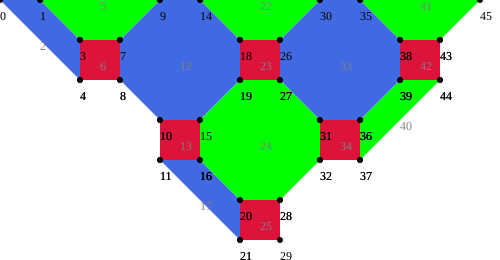

In [92]:
import svgwrite
from IPython.display import SVG, display
color_map = {
    'red':'crimson',
    'green':'lime',
    'blue':'royalblue'
    }


def draw_tiles(layout):
    width = max(x for tile in layout for x,y in tile.qubits)
    height = max(y for tile in layout for x,y in tile.qubits)
    drawing = svgwrite.Drawing(size = (width*20+20, height*20+20))
    qs = set()
    ans = set()
    for tile in layout:
        for q in tile.qubits:
            qs.add(q)
        ans.add(tile.ancilla)
    
    sorted_q_a = sorted(qs | ans)
    qa_index_map = {q:i for i,q in enumerate(sorted_q_a)}
    #print(qa_index_map)
    for tile in layout:
        drawing.add(drawing.polygon(
            points = [(x*20, y*20) for x,y in tile.qubits],
            fill = color_map[tile.color]
        ))
        #drawing.add(drawing.circle(center=(tile.ancilla[0]*20, tile.ancilla[1]*20), r=3, fill='grey'))
        drawing.add(drawing.text(str(qa_index_map[tile.ancilla]),insert=(tile.ancilla[0]*20, tile.ancilla[1]*20+10), fill='grey'))
        for x,y in tile.qubits:
            drawing.add(drawing.circle(center=(x*20, y*20), r=3, fill='black'))
            drawing.add(drawing.text(str(qa_index_map[(x,y)]),insert=(x*20, y*20+20), fill='black'))
    
    svg_data = drawing.tostring()
    display(SVG(svg_data))
    
def draw_tiles_indexed(tiles):
    width = max(x for tile in tiles for x,y in tile.qubits)
    height = max(y for tile in tiles for x,y in tile.qubits)
    drawing = svgwrite.Drawing(size = (width*20+20, height*20+20))
    sorted_q_a = sorted(CC.qubits | CC.ancilla)
    qa_index_map = {q:i for i,q in enumerate(sorted_q_a)}
    for tile in tiles:
        drawing.add(drawing.polygon(
            points = [(x*20, y*20) for x,y in tile.qubits],
            fill = color_map[tile.color]
        ))
        #drawing.add(drawing.circle(center=(tile.ancilla[0]*20, tile.ancilla[1]*20), r=3, fill='grey'))
        drawing.add(drawing.text(str(qa_index_map[tile.ancilla]),insert=(tile.ancilla[0]*20, tile.ancilla[1]*20+10), fill='grey'))
        for x,y in tile.qubits:
            drawing.add(drawing.circle(center=(x*20, y*20), r=3, fill='black'))
            drawing.add(drawing.text(str(qa_index_map[(x,y)]),insert=(x*20, y*20+20), fill='black'))
    
    svg_data = drawing.tostring()
    display(SVG(svg_data))

CC = ColorCodeCircuit488Debug(7,2)
layout = CC._generate_layout(7)
print(layout)
print(CC.qtoid)
#print(CC.get_circuit())
draw_tiles(layout)

In [83]:
import os
import stim

C:\Users\monam\OneDrive\Desktop\UNI\II\PartIIProject\CST-Part-II-Project-Code\color_code_experiments
Qubit with error index: 0
Detectors flipped: True
Observables flipped: True
-----------------------------

Qubit with error index: 1
Detectors flipped: True
-----------------------------

Qubit with error index: 2
Detectors flipped: False
-----------------------------

Qubit with error index: 3
Detectors flipped: True
Observables flipped: True
-----------------------------

Qubit with error index: 4
Detectors flipped: True
-----------------------------

Qubit with error index: 5
Detectors flipped: False
-----------------------------

Qubit with error index: 6
Detectors flipped: False
-----------------------------

Qubit with error index: 7
Detectors flipped: True
Observables flipped: True
-----------------------------

Qubit with error index: 8
Detectors flipped: True
-----------------------------

Qubit with error index: 9
Detectors flipped: True
-----------------------------

Qubit wi

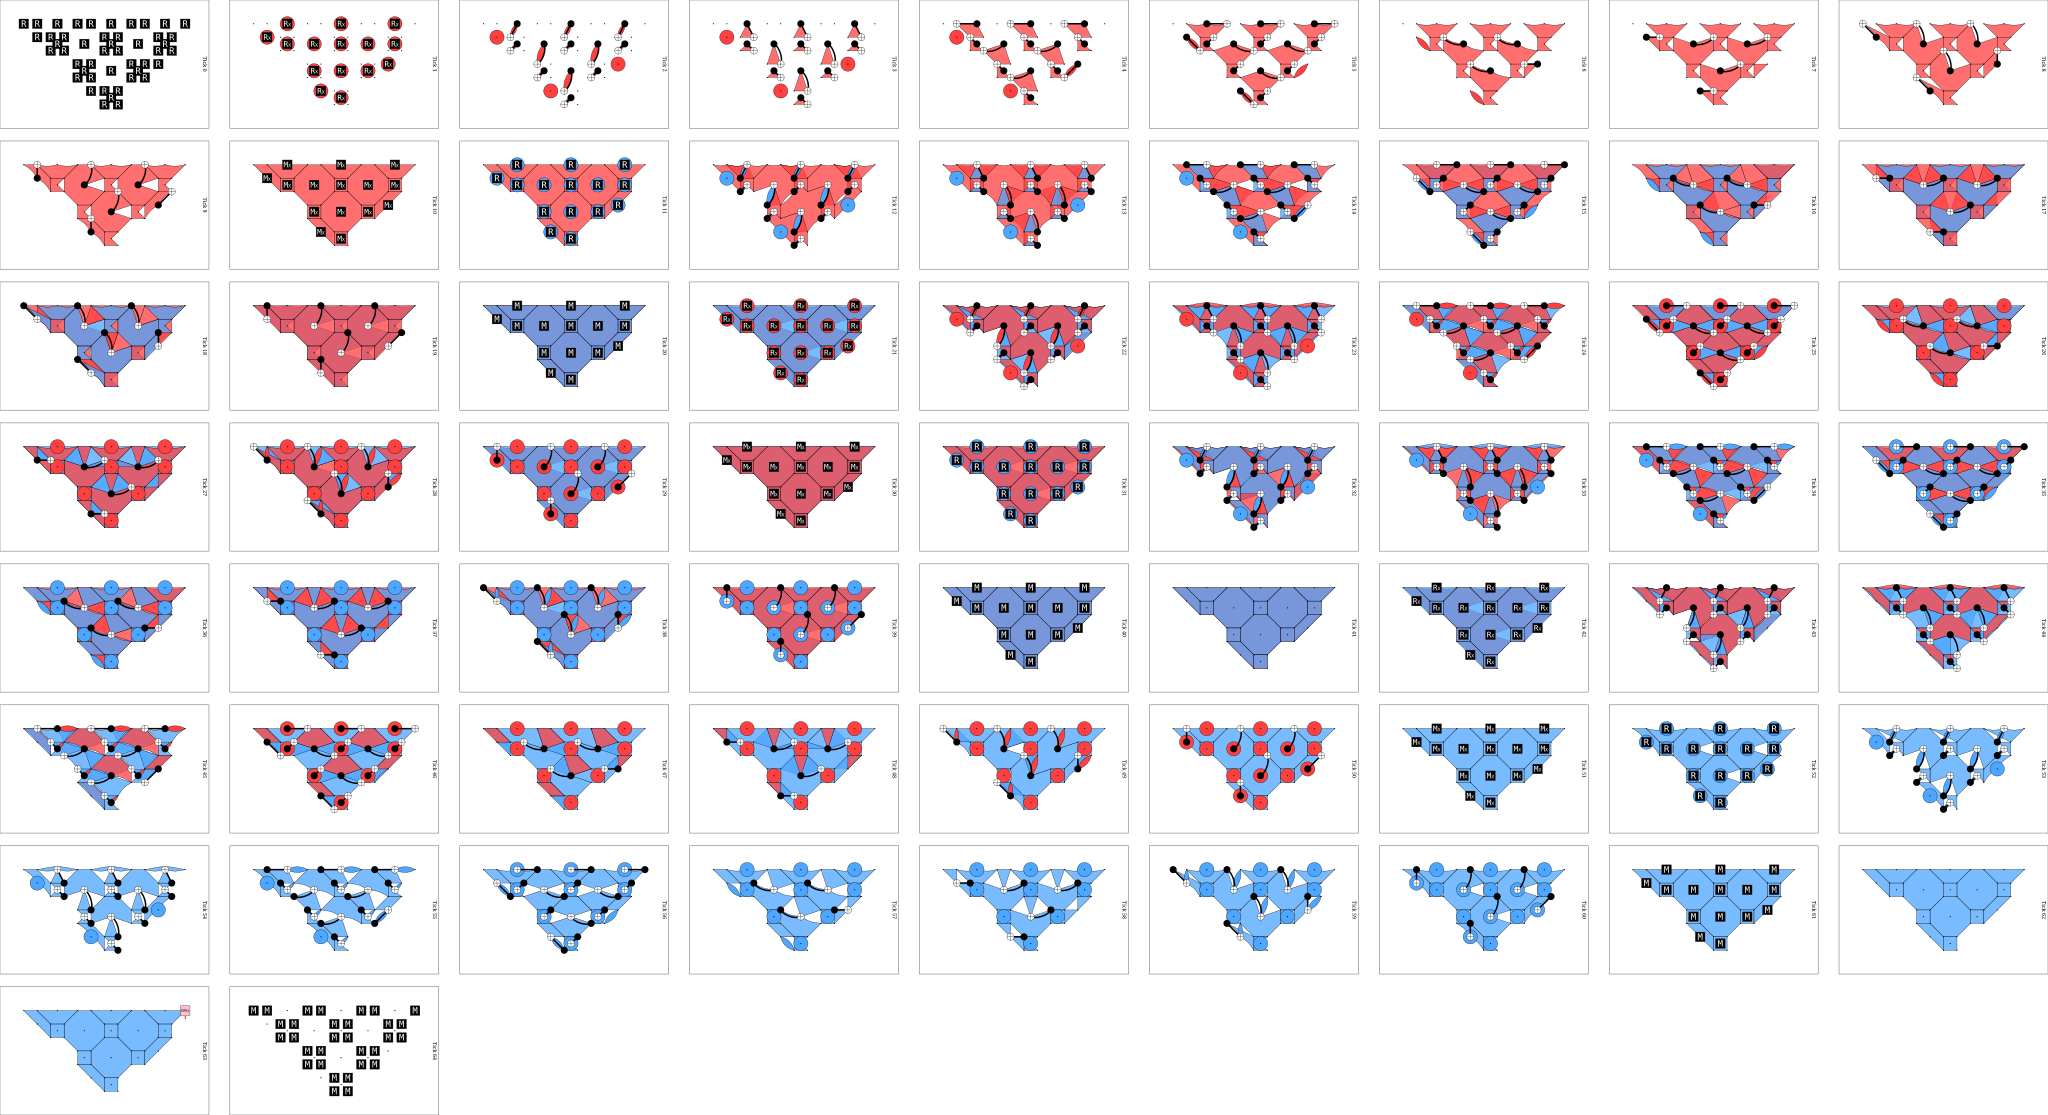

In [84]:

# 1. Navigate UP two levels to the project root:
#    preparation/ -> CST-Part-II-Project-Code/
#os.chdir('./color_code_experiments')
print(os.getcwd())

with open("singleerrorcirc.txt") as f:
    r = f.read()

for i in range(46):
    r_new = r.replace("X_ERROR(1)", f"X_ERROR(1) {i}")
    circ = stim.Circuit(r_new)
    dem = circ.detector_error_model()

    #explanation = circ.explain_detector_error_model_errors(
    #    dem_filter=dem, 
    #    reduce_to_one_representative_error=True
    #)
    #print(explanation)

    dem = circ.detector_error_model()

    sampler = stim.CompiledDetectorSampler(circ)
    # sample once with seed to see detectors:
    dets, obs = sampler.sample(shots=10, separate_observables=True)
    
    print(f"Qubit with error index: {i}")
    print("Detectors flipped:", dets.any())
    if (obs.any()):
        print("Observables flipped:", obs.any())
    
    print("-----------------------------\n")

circ.diagram("detslice-with-ops-svg")

In [89]:
#print out circuit for validation
CC2 = ColorCodeCircuit488Debug(5,3,0.01)
test_circuit = CC2.get_circuit()
print(test_circuit)
circ = CC2._build_circuit(noise=0.01)
sampler = stim.CompiledDetectorSampler(circ)
print((sampler.sample(shots=10000)).any())  # should be all zeros
dem = circ.detector_error_model()
#circuit_errors = circ.explain_detector_error_model_errors()
#print(circuit_errors)

number of logicals 1
target_idxs for logical = [0, 1, 2, 9, 14]
QUBIT_COORDS(0, 0) 0
QUBIT_COORDS(2, 2) 1
QUBIT_COORDS(2, 4) 2
QUBIT_COORDS(3, 0) 3
QUBIT_COORDS(3, 3) 4
QUBIT_COORDS(4, 2) 5
QUBIT_COORDS(4, 4) 6
QUBIT_COORDS(4, 6) 7
QUBIT_COORDS(6, 0) 8
QUBIT_COORDS(6, 6) 9
QUBIT_COORDS(6, 8) 10
QUBIT_COORDS(7, 3) 11
QUBIT_COORDS(7, 7) 12
QUBIT_COORDS(8, 0) 13
QUBIT_COORDS(8, 6) 14
QUBIT_COORDS(8, 8) 15
QUBIT_COORDS(10, 2) 16
QUBIT_COORDS(10, 4) 17
QUBIT_COORDS(11, 0) 18
QUBIT_COORDS(11, 3) 19
QUBIT_COORDS(12, 2) 20
QUBIT_COORDS(12, 4) 21
QUBIT_COORDS(14, 0) 22
QUBIT_COORDS(14, 2) 23
QUBIT_COORDS(16, 0) 24
R 0 1 2 5 6 8 9 10 13 14 15 16 17 20 21 22 24
X_ERROR(0.01) 0 1 2 5 6 8 9 10 13 14 15 16 17 20 21 22 24
R 3 4 7 11 12 18 19 23
X_ERROR(0.01) 3 4 7 11 12 18 19 23
TICK
RX 3 4 7 11 12 18 19 23
Z_ERROR(0.01) 3 4 7 11 12 18 19 23
TICK
CX 3 1 4 2 11 9 12 10 18 16 19 17
DEPOLARIZE2(0.01) 3 1 4 2 11 9 12 10 18 16 19 17
DEPOLARIZE1(0.01) 0 5 6 7 8 13 14 15 20 21 22 23 24
TICK
CX 3 5 4 6 11 14

In [90]:
dem = test_circuit.detector_error_model(decompose_errors=True)
print(dem.shortest_graphlike_error())
dem = circ.detector_error_model(decompose_errors=False)
print(dem)

error(1) L0
error(0.1130806635893793) D0
error(0.05089755021389318) D0 D1
error(0.05390564331077887) D0 D1 D3
error(0.006000449842759884) D0 D1 D3 D8
error(0.002006705456917236) D0 D1 D3 D8 D9
error(0.01389650090051903) D0 D1 D3 D8 D9 D11
error(0.0006697986788568588) D0 D1 D3 D8 D9 L0
error(0.0006697986788568588) D0 D1 D3 D8 L0
error(0.002006705456917236) D0 D1 D3 D9
error(0.0006697986788568588) D0 D1 D3 D11
error(0.002673815958446298) D0 D1 D8
error(0.02037788088851206) D0 D1 D8 D9 L0
error(0.005337801668914703) D0 D1 D8 L0
error(0.0006697986788568588) D0 D1 D9
error(0.02230280153587052) D0 D1 L0
error(0.05090160696683669) D0 D3
error(0.001338700097173321) D0 D3 D6
error(0.0006697986788568588) D0 D3 D6 D8 D9
error(0.0006697986788568588) D0 D3 D6 D8 D9 D11
error(0.001338700097173321) D0 D3 D6 D11
error(0.0006697986788568588) D0 D3 D6 D11 D13 D14
error(0.0006697986788568588) D0 D3 D6 D13 D14
error(0.01061861908451607) D0 D3 D8
error(0.007327534696472048) D0 D3 D8 D11
error(0.00066979867

In [9]:
#sampling
import chromobius
import numpy as np

CC_samp = ColorCodeCircuit488Debug(5,12,0.01)
samp_circuit = CC_samp.get_circuit()

sampler = samp_circuit.compile_detector_sampler()
dem = samp_circuit.detector_error_model()
decoder = chromobius.compile_decoder_for_dem(dem)

dets, actual_obs = sampler.sample(
    shots=50,
    separate_observables=True,
    bit_packed=True,
)

predicted_obs = decoder.predict_obs_flips_from_dets_bit_packed(dets)

mistakes = np.count_nonzero(np.any(predicted_obs != actual_obs, axis=1))
print(f'{mistakes=}')
print(predicted_obs)


number of logicals 1
target_idxs for logical = [0, 1, 2, 9, 14]
mistakes=np.int64(31)
[[1]
 [1]
 [0]
 [0]
 [1]
 [1]
 [0]
 [0]
 [1]
 [1]
 [1]
 [0]
 [1]
 [1]
 [1]
 [0]
 [0]
 [1]
 [0]
 [0]
 [0]
 [1]
 [0]
 [1]
 [1]
 [1]
 [0]
 [1]
 [0]
 [0]
 [0]
 [0]
 [1]
 [0]
 [1]
 [1]
 [1]
 [0]
 [1]
 [0]
 [0]
 [0]
 [1]
 [1]
 [1]
 [1]
 [0]
 [0]
 [0]
 [1]]


number of logicals 1
target_idxs for logical = [0, 3, 7]
number of logicals 1
target_idxs for logical = [0, 3, 7]
number of logicals 1
target_idxs for logical = [0, 3, 7]
number of logicals 1
target_idxs for logical = [0, 1, 2, 9, 14]
number of logicals 1
target_idxs for logical = [0, 1, 2, 9, 14]
number of logicals 1
target_idxs for logical = [0, 1, 2, 9, 14]
number of logicals 1
target_idxs for logical = [0, 3, 7, 10, 11, 20, 28]
number of logicals 1
target_idxs for logical = [0, 3, 7, 10, 11, 20, 28]
number of logicals 1
target_idxs for logical = [0, 3, 7, 10, 11, 20, 28]
number of logicals 1
target_idxs for logical = [0, 1, 2, 9, 14, 18, 19, 32, 41]
number of logicals 1
target_idxs for logical = [0, 1, 2, 9, 14, 18, 19, 32, 41]
number of logicals 1
target_idxs for logical = [0, 1, 2, 9, 14, 18, 19, 32, 41]


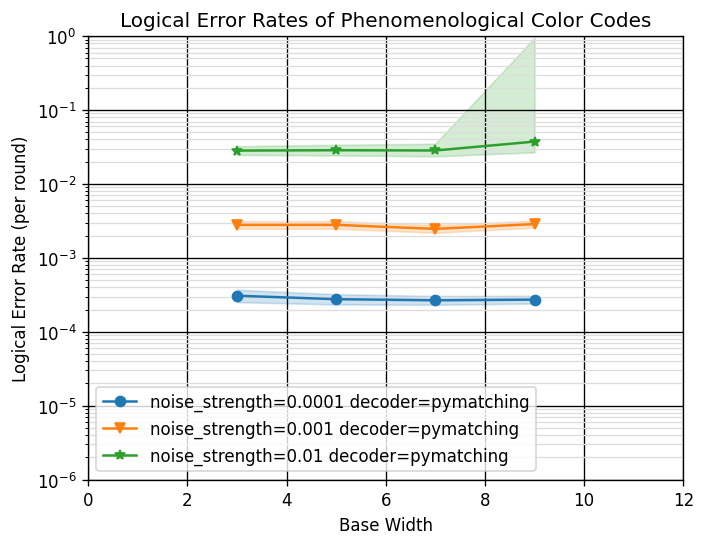

In [43]:
#plotting
import matplotlib.pyplot as plt
import os
import sinter

tasks = [
    sinter.Task(
        circuit=ColorCodeCircuit488Debug(d,r,p).get_circuit(),
        json_metadata={'d': d, 'p': p, 'r': r, 'b': b},
    )
    for d in [3,5,7,9]
    for r in [d*4]
    for b in ['Z']
    for p in [0.001,0.0001,0.01]
]

stats = sinter.collect(
    tasks=tasks,
    num_workers=os.cpu_count(),
    max_shots=100_000,
    max_errors=1000,
    print_progress=False,
    decoders=['pymatching'],
    #custom_decoders=chromobius.sinter_decoders(),
)

fig, ax = plt.subplots(1, 1)
sinter.plot_error_rate(
    ax=ax,
    stats=stats,
    x_func=lambda stat: stat.json_metadata['d'],
    group_func=lambda stat: f"""noise_strength={stat.json_metadata['p']} decoder={stat.decoder}""",
    failure_units_per_shot_func=lambda stat: stat.json_metadata['r'],
)
ax.set_ylim(1e-6, 1e-0)
ax.set_xlim(0, 12)
ax.semilogy()
ax.set_title("Logical Error Rates of Phenomenological Color Codes")
ax.set_xlabel("Base Width")
ax.set_ylabel("Logical Error Rate (per round)")
ax.grid(which='major', color='#000000')
ax.grid(which='minor', color='#DDDDDD')
ax.legend()
fig.set_dpi(120)  # Show it bigger



number of logicals 1
target_idxs for logical = [0, 3, 7]
number of logicals 1
target_idxs for logical = [0, 3, 7]
number of logicals 1
target_idxs for logical = [0, 3, 7]
number of logicals 1
target_idxs for logical = [0, 1, 2, 9, 14]
number of logicals 1
target_idxs for logical = [0, 1, 2, 9, 14]
number of logicals 1
target_idxs for logical = [0, 1, 2, 9, 14]
number of logicals 1
target_idxs for logical = [0, 3, 7, 10, 11, 20, 28]
number of logicals 1
target_idxs for logical = [0, 3, 7, 10, 11, 20, 28]
number of logicals 1
target_idxs for logical = [0, 3, 7, 10, 11, 20, 28]
number of logicals 1
target_idxs for logical = [0, 1, 2, 9, 14, 18, 19, 32, 41]
number of logicals 1
target_idxs for logical = [0, 1, 2, 9, 14, 18, 19, 32, 41]
number of logicals 1
target_idxs for logical = [0, 1, 2, 9, 14, 18, 19, 32, 41]


Starting 12 workers...
12 tasks left:
  workers    decoder        eta shots_left errors_left json_metadata        
        1 chromobius          ?     100000        1000 d=3,p=0.001,r=12,b=Z 
        1 chromobius          ?     100000        1000 d=3,p=0.0001,r=12,b=Z
        1 chromobius [draining]      96655        -282 d=3,p=0.01,r=12,b=Z  
        1 chromobius          ?     100000        1000 d=5,p=0.001,r=20,b=Z 
        1 chromobius          ?     100000        1000 d=5,p=0.0001,r=20,b=Z
        1 chromobius          ?     100000        1000 d=5,p=0.01,r=20,b=Z  
        1 chromobius          ?     100000        1000 d=7,p=0.001,r=28,b=Z 
        1 chromobius          ?     100000        1000 d=7,p=0.0001,r=28,b=Z
        1 chromobius          ?     100000        1000 d=7,p=0.01,r=28,b=Z  
        1 chromobius          ?     100000        1000 d=9,p=0.001,r=36,b=Z 
        1 chromobius          ?     100000        1000 d=9,p=0.0001,r=36,b=Z
        1 chromobius          ?     10

stats = [sinter.TaskStats(strong_id='77a0d6ed231ff2b8149a0a46f6ae8cf7616e90165704b565da6e997c31a9a41a', decoder='chromobius', json_metadata={'d': 3, 'p': 0.01, 'r': 12, 'b': 'Z'}, shots=3345, errors=np.int64(1282), seconds=0.0045014001079835), sinter.TaskStats(strong_id='f945e73b2e84902be7f6d057c1c49d3ed8dd87517d4a6459dc02beddffd47de4', decoder='chromobius', json_metadata={'d': 3, 'p': 0.001, 'r': 12, 'b': 'Z'}, shots=15633, errors=np.int64(1042), seconds=0.005976999935228378), sinter.TaskStats(strong_id='5c0eee8d552682d30dceb55ef7c2605bc6e6721f999b333fc60cfc0b2f4d9e6a', decoder='chromobius', json_metadata={'d': 5, 'p': 0.001, 'r': 20, 'b': 'Z'}, shots=12561, errors=np.int64(1038), seconds=0.016918000066652894), sinter.TaskStats(strong_id='06955b7ed546562bfe260f0490b10de4f5dc02d1d1ca61fb34a510d36fa64931', decoder='chromobius', json_metadata={'d': 5, 'p': 0.0001, 'r': 20, 'b': 'Z'}, shots=100000, errors=np.int64(956), seconds=0.05711690039606765), sinter.TaskStats(strong_id='1e5ffa26d65

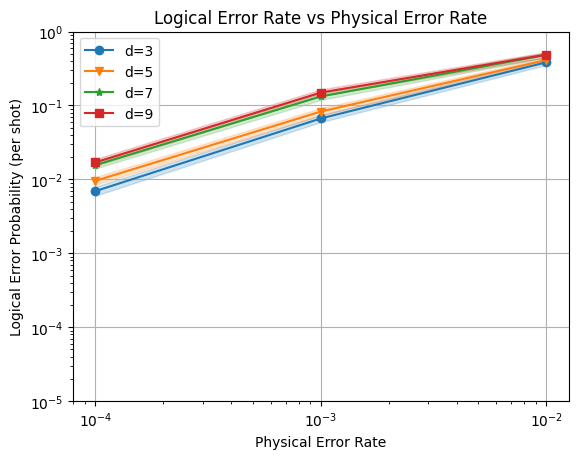

In [45]:
import matplotlib.pyplot as plt


tasks = [
    sinter.Task(
        circuit=ColorCodeCircuit488Debug(d,r,p).get_circuit(),
        json_metadata={'d': d, 'p': p, 'r': r, 'b': b},
    )
    for d in [3,5,7,9]
    for r in [d*4]
    for b in ['Z']
    for p in [0.001,0.0001,0.01]
]

stats = sinter.collect(
    tasks=tasks,
    num_workers=os.cpu_count(),
    max_shots=100_000,
    max_errors=1000,
    print_progress=True,
    decoders=['chromobius'],
    custom_decoders=chromobius.sinter_decoders(),
)
print(f'stats = {stats}')
# Render a matplotlib plot of the data.
fig, ax = plt.subplots(1, 1)
sinter.plot_error_rate(
    ax=ax,
    stats=stats,
    group_func=lambda stat: f"d={stat.json_metadata['d']}",
    x_func=lambda stat: stat.json_metadata['p'],
)
ax.loglog()
ax.set_ylim(1e-5, 1)
ax.grid()
ax.set_title('Logical Error Rate vs Physical Error Rate')
ax.set_ylabel('Logical Error Probability (per shot)')
ax.set_xlabel('Physical Error Rate')
ax.legend(title='488 Code Distance')
ax.legend()
for stat in stats:
    if stat.json_metadata['d']==11 or stat.json_metadata['d']==3:
        print(stat)
        print("--------------------------------------------")
# Save to file and also open in a window.
#fig.savefig('plot.png')
plt.show()

number of logicals 1
target_idxs for logical = [0, 3, 7]
number of logicals 1
target_idxs for logical = [0, 3, 7]
number of logicals 1
target_idxs for logical = [0, 3, 7]
number of logicals 1
target_idxs for logical = [0, 3, 7]
number of logicals 1
target_idxs for logical = [0, 3, 7]
number of logicals 1
target_idxs for logical = [0, 1, 2, 9, 14]
number of logicals 1
target_idxs for logical = [0, 1, 2, 9, 14]
number of logicals 1
target_idxs for logical = [0, 1, 2, 9, 14]
number of logicals 1
target_idxs for logical = [0, 1, 2, 9, 14]
number of logicals 1
target_idxs for logical = [0, 1, 2, 9, 14]
number of logicals 1
target_idxs for logical = [0, 3, 7, 10, 11, 20, 28]
number of logicals 1
target_idxs for logical = [0, 3, 7, 10, 11, 20, 28]
number of logicals 1
target_idxs for logical = [0, 3, 7, 10, 11, 20, 28]
number of logicals 1
target_idxs for logical = [0, 3, 7, 10, 11, 20, 28]
number of logicals 1
target_idxs for logical = [0, 3, 7, 10, 11, 20, 28]


Starting 12 workers...


number of logicals 1
target_idxs for logical = [0, 1, 2, 9, 14, 18, 19, 32, 41]
number of logicals 1
target_idxs for logical = [0, 1, 2, 9, 14, 18, 19, 32, 41]
number of logicals 1
target_idxs for logical = [0, 1, 2, 9, 14, 18, 19, 32, 41]
number of logicals 1
target_idxs for logical = [0, 1, 2, 9, 14, 18, 19, 32, 41]
number of logicals 1
target_idxs for logical = [0, 1, 2, 9, 14, 18, 19, 32, 41]


20 tasks left:
  workers    decoder        eta shots_left errors_left json_metadata    
        1 chromobius          ?     100000        1000 d=3,p=0.0001,r=12
        1 chromobius          ?     100000        1000 d=3,p=0.001,r=12 
        1 chromobius          ?     100000        1000 d=3,p=0.002,r=12 
        1 chromobius          ?     100000        1000 d=3,p=0.005,r=12 
        1 chromobius [draining]      96655        -274 d=3,p=0.01,r=12  
        1 chromobius          ?     100000        1000 d=5,p=0.0001,r=20
        1 chromobius          ?     100000        1000 d=5,p=0.001,r=20 
        1 chromobius          ?     100000        1000 d=5,p=0.002,r=20 
        1 chromobius          ?     100000        1000 d=5,p=0.005,r=20 
        1 chromobius          ?     100000        1000 d=5,p=0.01,r=20  
        1 chromobius          ?     100000        1000 d=7,p=0.0001,r=28
        1 chromobius          ?     100000        1000 d=7,p=0.001,r=28 
        0 chromobius        ?·∞     

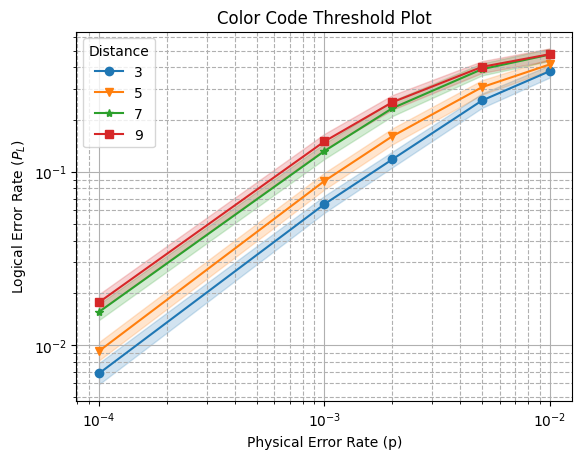

In [46]:
import sinter
import matplotlib.pyplot as plt
from typing import List
import chromobius

def generate_plot():
    distances = [3, 5, 7, 9]
    noise_levels = [0.0001, 0.001, 0.002, 0.005, 0.01]
    
    tasks = [
        sinter.Task(
            circuit=ColorCodeCircuit488Debug(d,r,p).get_circuit(),
            json_metadata={'d': d, 'p': p, 'r': r},
        )
        for d in distances
        for r in [d*4]
        for p in noise_levels
    ]

    # sampling
    samples = sinter.collect(
        tasks=tasks,
        num_workers=os.cpu_count(),
        max_shots=100_000,
        max_errors=1000,
        print_progress=True,
        decoders=['chromobius'],
        custom_decoders=chromobius.sinter_decoders(),
    )

    # plotting
    fig, ax = plt.subplots()
    sinter.plot_error_rate(
        ax=ax,
        stats=samples,
        x_func=lambda stats: stats.json_metadata['p'],
        group_func=lambda stats: stats.json_metadata['d'],
        failure_units_per_shot_func=lambda stats: 1,  # Probability per shot
    )

    ax.loglog()
    ax.set_title("Color Code Threshold Plot")
    ax.set_xlabel("Physical Error Rate (p)")
    ax.set_ylabel("Logical Error Rate ($P_L$)")
    ax.grid(which='major', linestyle='-')
    ax.grid(which='minor', linestyle='--')
    ax.legend(title='Distance')
    #plt.savefig("ImplCCThresholdPlot")
    plt.show()
generate_plot()